<a href="https://colab.research.google.com/github/ZeyadArafat/phase-3/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Dataset extracted successfully
/content/bdd100k
/content/bdd100k/bdd100k
/content/bdd100k/bdd100k/seg
/content/bdd100k/bdd100k/seg/color_labels
/content/bdd100k/bdd100k/seg/color_labels/val
/content/bdd100k/bdd100k/seg/color_labels/train
/content/bdd100k/bdd100k/seg/images
/content/bdd100k/bdd100k/seg/images/test
/content/bdd100k/bdd100k/seg/images/val
/content/bdd100k/bdd100k/seg/images/train
/content/bdd100k/bdd100k/seg/labels
/content/bdd100k/bdd100k/seg/labels/val
/content/bdd100k/bdd100k/seg/labels/train

Using image folder: /content/bdd100k/bdd100k/seg/labels/train
Total images found: 7000

Image Batch Shape: torch.Size([32, 64, 64])
Label Shape: torch.Size([32])

Model Architecture:

SimpleRNNClassifier(
  (rnn): RNN(64, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)


Epoch 1/3 Loss: 0.0005: 100%|██████████| 219/219 [01:47<00:00,  2.03it/s]



Epoch 1 Average Loss: 0.0418


Epoch 2/3 Loss: 0.0002: 100%|██████████| 219/219 [01:47<00:00,  2.03it/s]



Epoch 2 Average Loss: 0.0003


Epoch 3/3 Loss: 0.0001: 100%|██████████| 219/219 [01:44<00:00,  2.09it/s]



Epoch 3 Average Loss: 0.0002


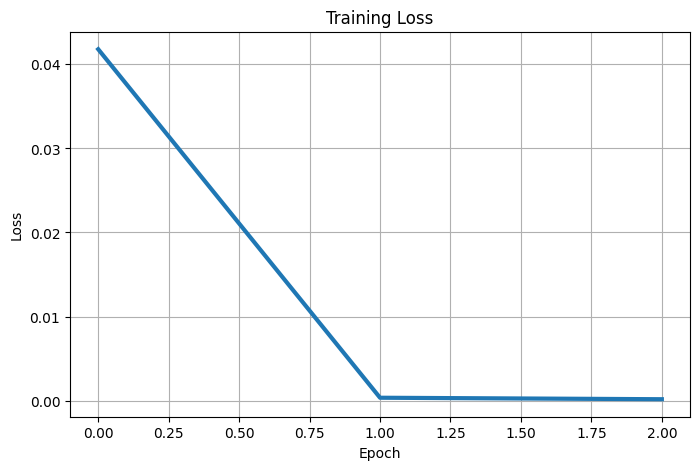


Predicted Classes:
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])


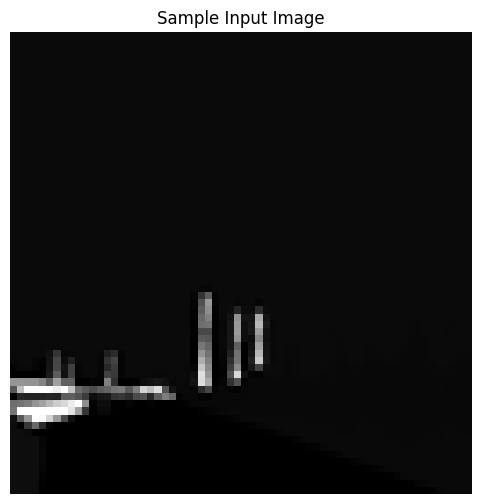


Model saved at: /content/simple_rnn_model.pth


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import zipfile
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

zip_path = "/content/bdd100k_seg.zip"
extract_path = "/content/bdd100k"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

for root, dirs, files in os.walk(extract_path):
    print(root)

DATA_PATH = "/content/bdd100k"

class BDD100KRNNDataset(Dataset):

    def __init__(self):

        possible_paths = [
            "/content/bdd100k/images/100k/train",
            "/content/bdd100k/images/10k/train",
            "/content/bdd100k/bdd100k/images/100k/train",
            "/content/bdd100k/bdd100k/images/10k/train",
            "/content/bdd100k/images/train",
            "/content/bdd100k/train",
            # Added path to segmentation labels
            "/content/bdd100k/bdd100k/seg/labels/train"
        ]

        self.images_folder = None

        for path in possible_paths:

            if os.path.exists(path):

                # Changed to look for .png files for segmentation masks
                target_files = [
                    file for file in os.listdir(path)
                    if file.endswith(".png")
                ]

                if len(target_files) > 0:
                    self.images_folder = path
                    break

        if self.images_folder is None:
            raise FileNotFoundError("Could not find image folder with .png segmentation labels")

        print(f"\nUsing image folder: {self.images_folder}")

        self.image_files = []

        for file in os.listdir(self.images_folder):

            # Changed to look for .png files
            if file.endswith(".png"):
                self.image_files.append(file)

        self.image_files.sort()

        print(f"Total images found: {len(self.image_files)}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        image_name = self.image_files[idx]

        image_path = os.path.join(self.images_folder, image_name)

        image = Image.open(image_path).convert("L")

        image = image.resize((64, 64))

        image = np.array(image) / 255.0

        image = torch.FloatTensor(image)

        label = torch.tensor(0)

        return image, label

train_dataset = BDD100KRNNDataset()

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

images, labels = next(iter(train_loader))

print("\nImage Batch Shape:", images.shape)
print("Label Shape:", labels.shape)

class SimpleRNNClassifier(nn.Module):

    def __init__(
        self,
        input_size=64,
        hidden_size=128,
        num_layers=2,
        num_classes=10
    ):

        super(SimpleRNNClassifier, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size
        ).to(device)

        out, hidden = self.rnn(x, h0)

        final_hidden_state = hidden[-1]

        output = self.fc(final_hidden_state)

        return output

model = SimpleRNNClassifier().to(device)

print("\nModel Architecture:\n")
print(model)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 3

training_losses = []

for epoch in range(epochs):

    model.train()

    total_loss = 0

    progress_bar = tqdm(train_loader)

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_description(
            f"Epoch {epoch+1}/{epochs} Loss: {loss.item():.4f}"
        )

    avg_loss = total_loss / len(train_loader)

    training_losses.append(avg_loss)

    print(f"\nEpoch {epoch+1} Average Loss: {avg_loss:.4f}")

plt.figure(figsize=(8,5))

plt.plot(training_losses, linewidth=3)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

model.eval()

images, labels = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():

    predictions = model(images)

    predicted_classes = torch.argmax(predictions, dim=1)

print("\nPredicted Classes:")
print(predicted_classes)

sample_image = images[0].cpu().numpy()

plt.figure(figsize=(6,6))

plt.imshow(sample_image, cmap='gray')

plt.title("Sample Input Image")

plt.axis("off")

plt.show()

save_path = "/content/simple_rnn_model.pth"

torch.save(model.state_dict(), save_path)

print(f"\nModel saved at: {save_path}")

Using device: cpu
Dataset extracted successfully
Total images found: 7000
SimpleRNNClassifier(
  (rnn): RNN(64, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)


Epoch 1/3 Loss: 2.3056: 100%|██████████| 175/175 [01:09<00:00,  2.52it/s]



Epoch 1
Training Loss: 2.3085
Validation Accuracy: 10.57%


Epoch 2/3 Loss: 2.2724: 100%|██████████| 175/175 [01:10<00:00,  2.48it/s]



Epoch 2
Training Loss: 2.3079
Validation Accuracy: 10.21%


Epoch 3/3 Loss: 2.3012: 100%|██████████| 175/175 [01:08<00:00,  2.56it/s]



Epoch 3
Training Loss: 2.3056
Validation Accuracy: 11.21%


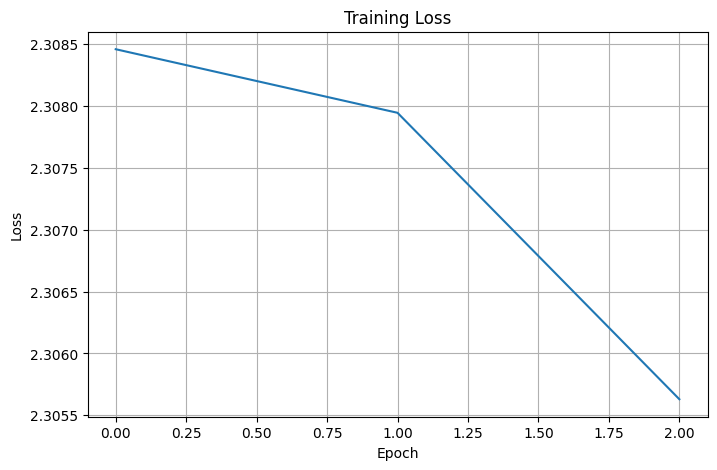

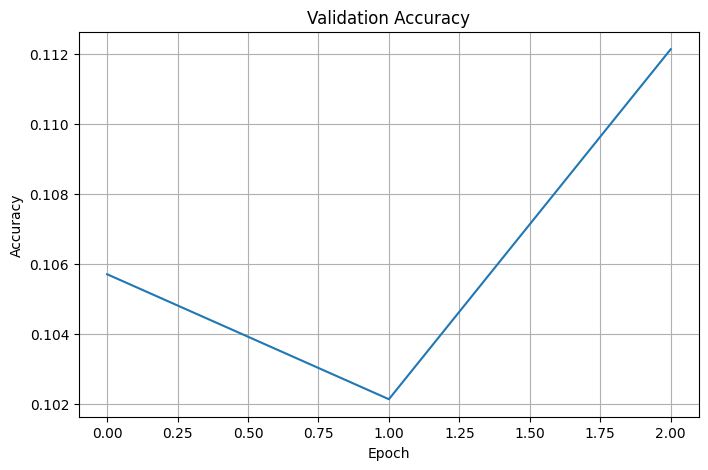

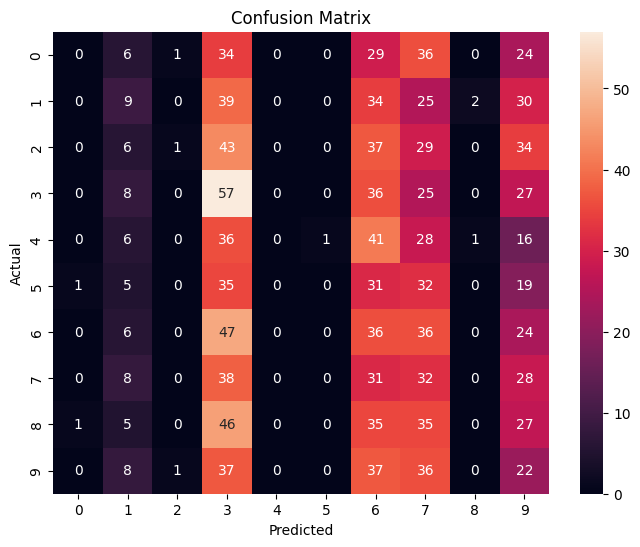

Model saved at: /content/simple_rnn_model.pth


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import zipfile
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

zip_path = "/content/bdd100k_seg.zip"
extract_path = "/content/bdd100k"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

IMAGE_PATH = "/content/bdd100k/bdd100k/seg/images/train"

class BDD100KRNNDataset(Dataset):

    def __init__(self, image_folder):

        self.image_folder = image_folder

        self.image_files = [
            file for file in os.listdir(image_folder)
            if file.endswith(".jpg")
        ]

        self.image_files.sort()

        print(f"Total images found: {len(self.image_files)}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        image_name = self.image_files[idx]

        image_path = os.path.join(self.image_folder, image_name)

        image = Image.open(image_path).convert("L")

        image = image.resize((64, 64))

        image = np.array(image) / 255.0

        image = torch.FloatTensor(image)

        label = torch.tensor(np.random.randint(0, 10))

        return image, label

dataset = BDD100KRNNDataset(IMAGE_PATH)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

class SimpleRNNClassifier(nn.Module):

    def __init__(
        self,
        input_size=64,
        hidden_size=128,
        num_layers=2,
        num_classes=10
    ):

        super(SimpleRNNClassifier, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size
        ).to(device)

        out, hidden = self.rnn(x, h0)

        final_hidden_state = hidden[-1]

        output = self.fc(final_hidden_state)

        return output

model = SimpleRNNClassifier().to(device)

print(model)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 3

train_losses = []
val_accuracies = []

for epoch in range(epochs):

    model.train()

    total_loss = 0

    progress_bar = tqdm(train_loader)

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_description(
            f"Epoch {epoch+1}/{epochs} Loss: {loss.item():.4f}"
        )

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)

    val_accuracies.append(accuracy)

    print(f"\nEpoch {epoch+1}")
    print(f"Training Loss: {avg_loss:.4f}")
    print(f"Validation Accuracy: {accuracy*100:.2f}%")

plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(val_accuracies)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

save_path = "/content/simple_rnn_model.pth"

torch.save(model.state_dict(), save_path)

print(f"Model saved at: {save_path}")